# 06 — Mechanism: batching, step cost and AMX use

**Objective.** Explain *why* the two servers scale so differently with concurrency (notebook 04).

**Research question.** Do both servers batch concurrent requests, and if they do, what limits llama.cpp — batch
formation, the cost of a batched forward step, AMX use, or core occupancy?

**Data.** Telemetry aggregated over each repetition's steady window (`online_points`): the servers' own step and
token counters (vLLM `iteration_tokens_total`, llama.cpp `n_decode_total` and token counters), `EXE.AMX_BUSY` per
cycle, busy fraction of compute cores 0–54, and effective clock.

**Method.** Tokens per forward step = processed tokens ÷ forward steps in the window; step time = 1 ÷ steps per
second. `EXE.AMX_BUSY / cycles` is the fraction of core cycles in which the AMX unit is busy — a utilization
indicator, not a share of FLOPs.

**Assumptions and limits.** There is no AMX-on/AMX-off ablation in this dataset (both engines were run as built
with AMX enabled); AMX's contribution is inferred from activity counters and from the BF16 (no AMX in llama.cpp)
vs INT8 (AMX-INT8 in llama.cpp) contrast, which is confounded with precision.

In [1]:
import pandas as pd
from IPython.display import display

from llm_backend_analysis.analysis import comparisons, memory, metrics
from llm_backend_analysis.data import loaders, registry
from llm_backend_analysis.reporting import Claim, claims_table, num, pct, rng, show, table, x
from llm_backend_analysis.visualization import plots, theme
from llm_backend_analysis.visualization.export import export_figure

theme.setup_notebook()
NOTEBOOK = "06_batching_and_amx.ipynb"
MODEL = registry.primary_model()  # Llama-3.1-8B-Instruct; the 1B model is the cross-check

In [2]:
pts = metrics.add_step_metrics(loaders.online_points())
primary = pts[pts["model"] == MODEL]

## 1. Do both servers batch?

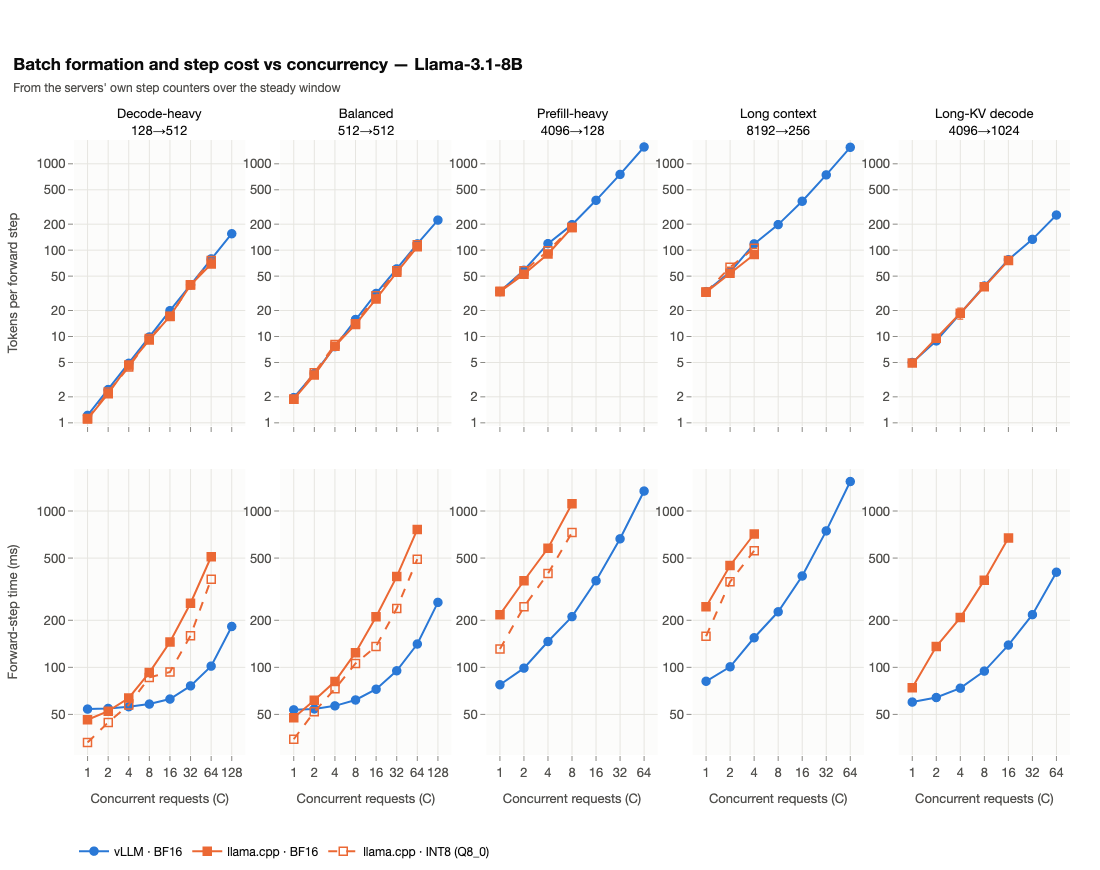

In [3]:
fig = plots.concurrency_grid(primary, [
    plots.Panel("tokens_per_step_mean", "Tokens per forward step", "tokens", log_y=True, share_y=True, fmt=".1f"),
    plots.Panel("step_time_s", "Forward-step time (ms)", "ms", scale=1e3, log_y=True, share_y=True, error=None),
], title=f"Batch formation and step cost vs concurrency — {registry.model_label(MODEL)}",
   subtitle="From the servers' own step counters over the steady window")
fig.show()

In [4]:
growth = metrics.step_cost_growth(primary)
growth = growth.assign(per_token_cost_drop=growth["batch_growth"] / growth["step_time_growth"],
                       configuration=growth["configuration_id"].map(registry.configuration_label),
                       workload=growth["workload"].map(lambda w: registry.workload_label(w, short=True)))
display(table(growth[["workload", "configuration", "c_first", "c_last", "tokens_per_step_first", "tokens_per_step_last",
                      "step_time_first_s", "step_time_last_s", "step_time_growth", "per_token_cost_drop"]]
              .assign(step_time_first_s=growth["step_time_first_s"] * 1e3, step_time_last_s=growth["step_time_last_s"] * 1e3)
              .rename(columns={"workload": "Workload", "configuration": "Configuration", "c_first": "C from", "c_last": "C to",
                               "tokens_per_step_first": "Tokens/step at C from", "tokens_per_step_last": "Tokens/step at C to",
                               "step_time_first_s": "Step (ms) at C from", "step_time_last_s": "Step (ms) at C to",
                               "step_time_growth": "Step-time growth",
                               "per_token_cost_drop": "Per-token cost drop (batch growth ÷ step growth)"}),
              {"Tokens/step at C from": "{:.1f}", "Tokens/step at C to": "{:.0f}", "Step (ms) at C from": "{:.0f}",
               "Step (ms) at C to": "{:.0f}", "Step-time growth": "{:.1f}×",
               "Per-token cost drop (batch growth ÷ step growth)": "{:.1f}×"}))
g = growth.set_index(["configuration_id", "workload"])["per_token_cost_drop"]
eq = primary[primary["workload"].isin(["decode", "balanced"])]
at64 = eq[eq["concurrency"] == 64].set_index(["workload", "configuration_id"])
show(f"At C = 64 on the short-prompt shapes both servers process about the same number of tokens per step "
     f"(vLLM BF16 {rng(at64.xs('vllm_bf16', level=1)['tokens_per_step_mean'])}, llama.cpp BF16 "
     f"{rng(at64.xs('llama_cpp_bf16', level=1)['tokens_per_step_mean'])}), but a llama.cpp BF16 step takes "
     f"{rng(at64.xs('llama_cpp_bf16', level=1)['step_time_s'] / at64.xs('vllm_bf16', level=1)['step_time_s'], x)} as long as a vLLM step. "
     f"Over the whole sweep the cost per token of a step falls by {rng(g.loc['vllm_bf16'], x)} for vLLM BF16 and by "
     f"{rng(g.loc['llama_cpp_bf16'], x)} for llama.cpp BF16.")

Workload,Configuration,C from,C to,Tokens/step at C from,Tokens/step at C to,Step (ms) at C from,Step (ms) at C to,Step-time growth,Per-token cost drop (batch growth ÷ step growth)
128→512,vLLM · BF16,1,128,1.2,155,54,183,3.4×,37.6×
128→512,llama.cpp · BF16,1,64,1.1,69,46,510,11.0×,5.7×
128→512,llama.cpp · INT8 (Q8_0),1,64,1.1,76,33,366,11.1×,6.1×
512→512,vLLM · BF16,1,128,2.0,223,53,260,4.9×,23.3×
512→512,llama.cpp · BF16,1,64,1.9,109,48,762,16.0×,3.6×
512→512,llama.cpp · INT8 (Q8_0),1,64,1.9,116,35,492,14.2×,4.3×
4096→128,vLLM · BF16,1,64,33.1,1567,77,1341,17.3×,2.7×
4096→128,llama.cpp · BF16,1,8,33.0,183,217,1113,5.1×,1.1×
4096→128,llama.cpp · INT8 (Q8_0),1,8,33.4,183,131,728,5.6×,1.0×
8192→256,vLLM · BF16,1,64,33.1,1553,81,1544,19.0×,2.5×


At C = 64 on the short-prompt shapes both servers process about the same number of tokens per step (vLLM BF16 79–118, llama.cpp BF16 69–109), but a llama.cpp BF16 step takes 5.0×–5.4× as long as a vLLM step. Over the whole sweep the cost per token of a step falls by 2.5×–37.6× for vLLM BF16 and by 0.9×–5.7× for llama.cpp BF16.

**Interpretation.** Batching is not what limits llama.cpp: with one slot per in-flight request and continuous
batching, its batches grow with C just like vLLM's. What differs is the cost of a batched step. vLLM's step time
grows far more slowly than the batch, so the cost per token falls steeply and more tokens per step become more
tokens per second. llama.cpp's step time grows much faster with the batch, so its cost per token falls only a few
times and additional concurrent requests add little throughput.

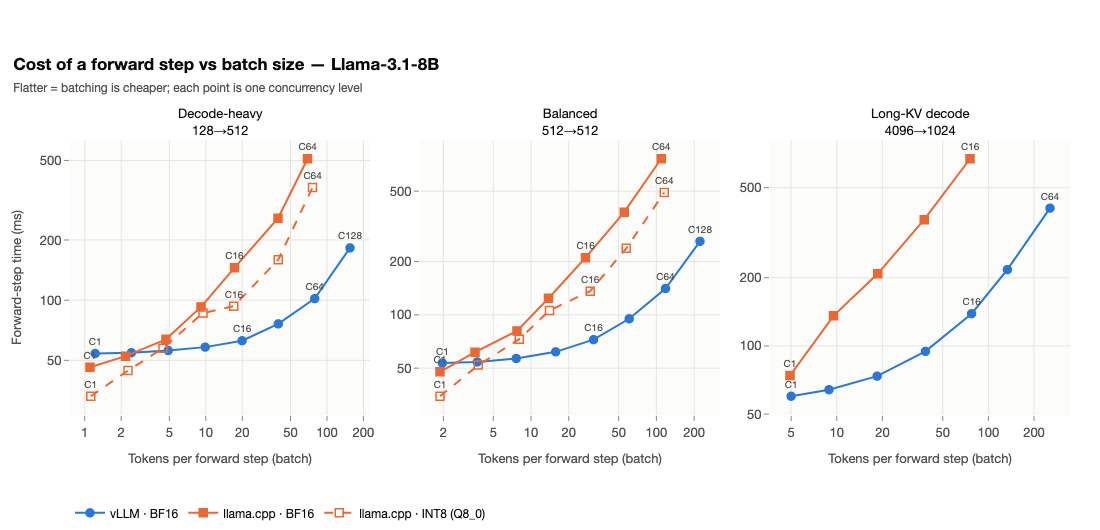

In [5]:
fig = plots.path_scatter(primary[primary["workload"].isin(["decode", "balanced", "kvdecode"])],
                         x="tokens_per_step_mean", y="step_time_s", y_scale=1e3, log_x=True, log_y=True,
                         x_title="Tokens per forward step (batch)", y_title="Forward-step time (ms)",
                         title=f"Cost of a forward step vs batch size — {registry.model_label(MODEL)}",
                         subtitle="Flatter = batching is cheaper; each point is one concurrency level",
                         label_cs=(1, 16, 64))
fig.show()
export_figure(fig, "step_cost_vs_batch", source=NOTEBOOK,
              caption="Forward-step time vs tokens per step (8B, short-prompt and long-KV shapes): vLLM steps stay cheap as batches grow.")

## 2. AMX activity, core occupancy and clock

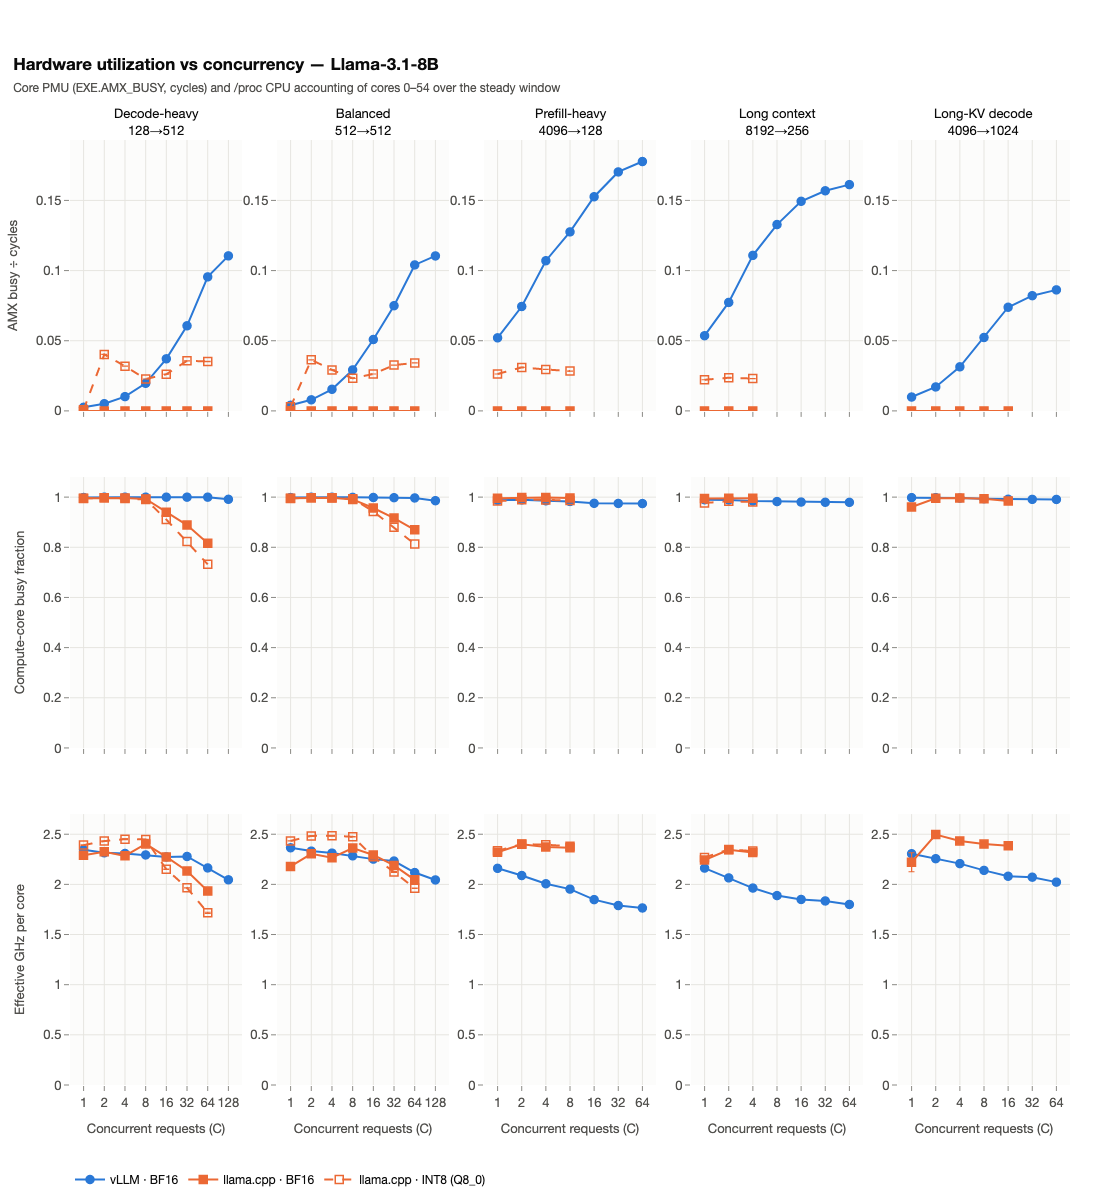

In [6]:
fig = plots.concurrency_grid(primary, [
    plots.Panel("amx_busy_frac_mean", "AMX busy ÷ cycles", "", share_y=True, fmt=".3f"),
    plots.Panel("cpu_busy_compute_mean_mean", "Compute-core busy fraction", "", share_y=True, fmt=".3f",
                range_to_zero=False),
    plots.Panel("ghz_effective_per_core_mean", "Effective GHz per core", "GHz", share_y=True, fmt=".2f",
                range_to_zero=False),
], title=f"Hardware utilization vs concurrency — {registry.model_label(MODEL)}",
   subtitle="Core PMU (EXE.AMX_BUSY, cycles) and /proc CPU accounting of cores 0–54 over the steady window")
fig.show()

In [7]:
hi = primary.loc[primary.groupby(["configuration_id", "workload"])["concurrency"].idxmax()].set_index(["configuration_id", "workload"])
lo = primary[primary["concurrency"] == 1].set_index(["configuration_id", "workload"])
show(f"AMX busy fraction from C=1 to the highest C: vLLM BF16 {rng(lo.loc['vllm_bf16', 'amx_busy_frac_mean'], pct, nd=1, signed=False)} → "
     f"{rng(hi.loc['vllm_bf16', 'amx_busy_frac_mean'], pct, nd=1, signed=False)}; llama.cpp BF16 "
     f"{rng(primary[primary['configuration_id'] == 'llama_cpp_bf16']['amx_busy_frac_mean'], pct, nd=1, signed=False)} at every C; "
     f"llama.cpp INT8 {rng(primary[primary['configuration_id'] == 'llama_cpp_int8']['amx_busy_frac_mean'], pct, nd=1, signed=False)}. "
     f"Compute-core busy at the highest C: vLLM {rng(hi.loc['vllm_bf16', 'cpu_busy_compute_mean_mean'], pct, nd=1, signed=False)}, "
     f"llama.cpp BF16 {rng(hi.loc['llama_cpp_bf16', 'cpu_busy_compute_mean_mean'], pct, nd=1, signed=False)}, "
     f"llama.cpp INT8 {rng(hi.loc['llama_cpp_int8', 'cpu_busy_compute_mean_mean'], pct, nd=1, signed=False)}.")

AMX busy fraction from C=1 to the highest C: vLLM BF16 0.3%–5.4% → 8.6%–17.8%; llama.cpp BF16 0.0% at every C; llama.cpp INT8 0.1%–4.0%. Compute-core busy at the highest C: vLLM 97.4%–99.1%, llama.cpp BF16 81.6%–99.7%, llama.cpp INT8 73.2%–98.6%.

**Interpretation.**
- vLLM's AMX activity rises steadily with concurrency while all compute cores stay busy and the effective clock
  drops slightly (AMX-heavy code lowers the frequency): vLLM turns batch size into matrix work that the AMX units
  execute, and it saturates by compute at high C.
- llama.cpp BF16 never uses AMX (it has no BF16 AMX kernel), and on the short-prompt shapes its core occupancy
  *falls* at high C — its large batched steps contain phases that do not keep all cores busy. The earlier counter-based study attributed most of
  llama.cpp's batched cost to attention; that attribution was not re-measured in this campaign.
- llama.cpp INT8 does execute AMX instructions, but at a low busy fraction, and it plateaus at the same C as BF16:
  AMX in the weight GEMMs alone does not change the shape of llama.cpp's scaling curve.

These observations support, but do not prove, that AMX coverage of the batched computation (GEMMs *and*
attention) is the main reason vLLM scales; an AMX ablation would be needed to quantify it.

## Conclusions

- **Measured:** both servers form batches of about C tokens per step; the cost per token of a vLLM step falls
  much more with batch size than llama.cpp's. vLLM's AMX activity grows with load; llama.cpp BF16 uses none, INT8 little.
- **Interpretation:** vLLM's scaling comes from cheap batched steps backed by AMX; llama.cpp's limit is its
  per-step execution cost at large batch, not batch formation and not memory bandwidth (notebook 07).
- **Implication for the thesis:** vLLM exercises the Xeon Max's AMX path under concurrent load, which is the
  regime the thesis studies; llama.cpp would leave most of the concurrency range compute-idle.

## Limitations

- No AMX ablation (AMX off / AVX-512 only) was run for either engine in this campaign.
- Tokens per step mixes prefill chunks and decode tokens; it shows that batching happens, not how efficiently.
- AMX busy is a utilization counter, not a throughput or FLOP measure.